## Topic Discovery and Text Pattern Analysis of Economy-Related YouTube Comments

### Project Overview

This notebook is the third stage of the project and focuses on uncovering higher-level patterns in the cleaned YouTube comment corpus.

After collecting economy-related videos and comments and preparing the dataset for analysis, this stage moves from descriptive inspection to text representation and unsupervised pattern discovery. The goal is to identify recurring themes, salient terms, and interpretable topic structures in public discussion of economy-related news content.

### Text Representation for Corpus-Level Analysis

To analyze recurring themes in the comment corpus, the first step is to transform the cleaned text into a structured representation that can be used for corpus-level analysis.

In this notebook, I use document-term representations to summarize how words are distributed across comments. This provides the foundation for identifying frequent terms, comparing vocabulary patterns, and applying topic modeling methods.

In [1]:
import pandas as pd
df = pd.read_csv('yt_comments_cleaned.csv')

In [2]:
df.head()

,channel_name,video_id,video_title,video_creation_time,video_number_of_views,comment_id,comment_title,comment_creation_time,comment_number_of_likes
0,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26 15:32:49,51869,Ugwe-foTG3moc3xxtrd4AaABAg,America is toast,2026-01-26 15:34:36,98
1,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26 15:32:49,51869,Ugyou95rzVIIpfOBBpR4AaABAg,He's going for the yugest bankruptcy of his li...,2026-01-26 15:41:47,35
2,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26 15:32:49,51869,Ugy1uAYCCiQLEkcgz4F4AaABAg,Gold only surge when economic not stable,2026-01-26 15:35:51,44
3,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26 15:32:49,51869,UgzjmzQUiJf5Dyxz73Z4AaABAg,Because the world doesn’t trust the us dollar ...,2026-01-26 15:44:13,91
4,CNN,L5tvym36mO0,Gold surges to record $5000 price,2026-01-26 15:32:49,51869,UgzZIZEgQGeu38XsEB14AaABAg,We were told this day would come! invest in go...,2026-01-26 16:09:36,10


I use the `comment_title` field as the input for document-term matrix construction because it contains the actual user-generated text that reflects public reactions to economy-related videos.

Each comment can be treated as a short document, which makes this field appropriate for corpus-level text analysis. In contrast, video-level metadata is useful for contextual analysis, but it is less suitable as the primary text unit for term-based modeling.

In [ ]:
# exclude common English stopwords
# get stop words list
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import CountVectorizer

stop_words = text.ENGLISH_STOP_WORDS
stop_words = list(stop_words)

In [4]:
stop_words[:10]

['often',
 'upon',
 'couldnt',
 'whither',
 'am',
 'toward',
 'put',
 'are',
 'becomes',
 'because']

In [ ]:
# exclude common English stopwords
# apply to comment_title column
cv = CountVectorizer(stop_words=stop_words)
df_cv = cv.fit_transform(df['comment_title'])
df1 = pd.DataFrame(df_cv.toarray(), columns=cv.get_feature_names_out())
df1.index = df['comment_id']

In [6]:
df1.head()

,00,000,04,05,080,09,10,100,1000,100k,...,zimbabwean,zip,zips,zombie,zone,zoom,zwykłym,zzz,übersetzung,że
comment_id,,,,,,,,,,,,,,,,,,,,,
Ugwe-foTG3moc3xxtrd4AaABAg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Ugyou95rzVIIpfOBBpR4AaABAg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Ugy1uAYCCiQLEkcgz4F4AaABAg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
UgzjmzQUiJf5Dyxz73Z4AaABAg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
UgzZIZEgQGeu38XsEB14AaABAg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


The initial document-term matrix still contains tokens such as numbers and other low-value patterns that are not especially useful for interpreting public discourse. To make the matrix cleaner and easier to interpret, I restrict the vocabulary to alphabetic tokens with at least two characters.

This improves the quality of the representation by reducing noise and making the most frequent terms more substantively meaningful.

In [7]:
cv1 = CountVectorizer(stop_words=stop_words, token_pattern=r'(?u)\b[a-zA-Z]{2,}\b')  # more cleaning
df_cv1 = cv1.fit_transform(df['comment_title'])
df2 = pd.DataFrame(df_cv1.toarray(), columns=cv1.get_feature_names_out())
df2.index = df['comment_id']

In [8]:
df2.head()

,abandon,abandoning,abandons,abbot,abc,abdicated,abdicators,abetting,ability,able,...,zee,zero,zilch,zimbabwean,zip,zips,zombie,zone,zoom,zzz
comment_id,,,,,,,,,,,,,,,,,,,,,
Ugwe-foTG3moc3xxtrd4AaABAg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Ugyou95rzVIIpfOBBpR4AaABAg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Ugy1uAYCCiQLEkcgz4F4AaABAg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
UgzjmzQUiJf5Dyxz73Z4AaABAg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
UgzZIZEgQGeu38XsEB14AaABAg,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


After removing common stopwords and filtering out low-value token patterns such as standalone numbers, the document-term matrix becomes much more interpretable and better suited for downstream text analysis.

### Frequent Terms and Salient Vocabulary

Before moving into topic discovery, I first examine the most common words in the corpus. Looking at frequent terms provides an initial sense of what ideas dominate the discussion and whether the cleaned vocabulary is capturing meaningful economy-related language.

This step also makes later topic-model interpretations easier to understand.

In [ ]:
top_30 = df2.sum(axis=0).sort_values(ascending=False).head(30)  # sort the words on frequency and keep the top 30
top_words = list(zip(top_30.index, top_30.values))  # combine into (word, count) pairs
top_words

[('trump', np.int64(437)),
 ('people', np.int64(339)),
 ('prices', np.int64(213)),
 ('just', np.int64(199)),
 ('economy', np.int64(181)),
 ('like', np.int64(166)),
 ('don', np.int64(144)),
 ('money', np.int64(134)),
 ('president', np.int64(130)),
 ('america', np.int64(130)),
 ('inflation', np.int64(127)),
 ('going', np.int64(126)),
 ('know', np.int64(106)),
 ('great', np.int64(100)),
 ('year', np.int64(99)),
 ('time', np.int64(98)),
 ('make', np.int64(95)),
 ('good', np.int64(94)),
 ('way', np.int64(90)),
 ('american', np.int64(89)),
 ('want', np.int64(87)),
 ('need', np.int64(85)),
 ('biden', np.int64(83)),
 ('years', np.int64(78)),
 ('doesn', np.int64(73)),
 ('country', np.int64(72)),
 ('news', np.int64(72)),
 ('insurance', np.int64(71)),
 ('right', np.int64(68)),
 ('government', np.int64(67))]

#### Interpreting the Most Frequent Terms

Since the videos I selected were all centered on the economy, it makes sense that the top words are strongly tied to that theme, especially words like `prices,` `economy,` and `inflation.` These are very direct economic terms, and some of them were also included in the five keywords I identified for the economy theme back in Assignment 1.

I also noticed two interesting patterns. First, the connection between the economy and politics seems very strong. The most frequent word was `trump,` and since I used CountVectorizer to build the DTM, which to my knowledge converts text to lowercase, I do not really doubt that this is referring to President Trump. Similarly, words like `president,` `government,` and `biden` also show up among the top terms, which suggests that discussions about the economy are often political in nature. That is not too surprising, since people usually see economic policy and overall economic conditions as being closely tied to the government’s performance.

The second thing I found interesting is that, based on these top words, the tone of the comments seems relatively positive. Words like `like,` `great,` and `good` appear quite often, which may suggest that many people are expressing supportive reactions in their economic discussions.

### Visualizing High-Frequency Terms

To complement the frequency table, I use visualizations to examine the structure of the most common words in the corpus.

The goal here is not only to confirm which words are frequent, but also to make the broader vocabulary distribution easier to interpret visually.

#### Choice of Visualizations

I use two visualizations to examine the most frequent terms in the corpus: a word cloud and a horizontal bar chart.

The word cloud provides a quick visual summary of which terms dominate the corpus, while the horizontal bar chart makes it easier to compare specific word frequencies directly. Together, these two views balance intuitive pattern recognition with more precise comparison.

In [10]:
!pip install wordcloud

In [ ]:
# visualization 1 (word cloud)
# convert top_words into dict
word_cloud_dict = dict(top_words)

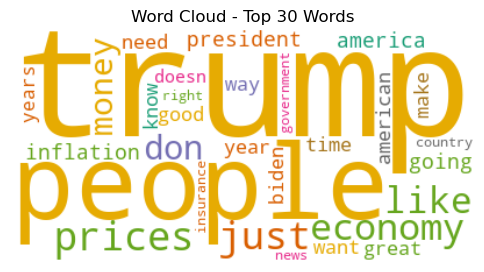

In [ ]:
# visualization 1
# generate word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# create word cloud object
wc = WordCloud(background_color="white", colormap="Dark2",
               max_font_size=150, random_state=42)  # already apply stopwords rule

# plotting
plt.rcParams['figure.figsize'] = [6, 6]

wc.generate_from_frequencies(word_cloud_dict)

plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Top 30 Words")
plt.show()

In [13]:
# visualization 2 (horizontal bar chart)
# convert top_words into words & counts lists
words = [word for word, count in top_words]
counts = [int(count) for word, count in top_words]  # for frequency labeling

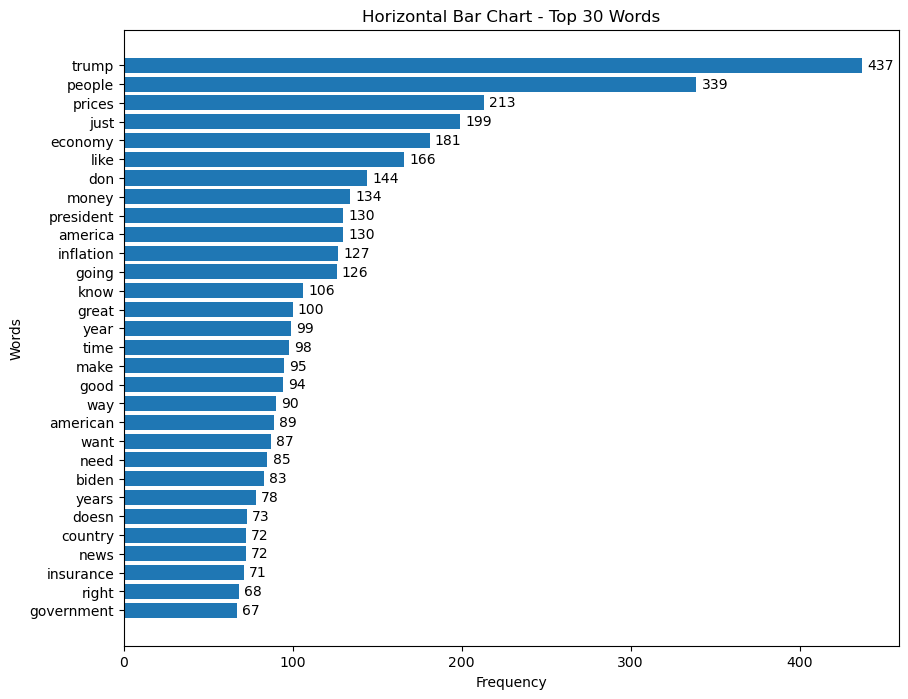

In [14]:
# visualization 2 (horizontal bar chart)
# I want the most frequent word at the top so order reversion 
words = words[::-1]
counts = counts[::-1]

# plotting
plt.figure(figsize=(10, 8))
plt.barh(words, counts)

for i, v in enumerate(counts): 
    plt.text(v + 3, i, str(v), va='center')  # add frequency labels to each bar

plt.title("Horizontal Bar Chart - Top 30 Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

#### Insights from the Visualizations

In addition to the observations I already made, these two visualizations helped me draw a few more inferences.

- The **word cloud** gave me a more intuitive sense of the overall structure of the top 30 words, which matches exactly why I chose this visualization in the first place. When I was only browsing the list of top words with the naked eye, some patterns were less obvious to me. But once I looked at the word cloud, I noticed more clearly about the presence of some words like `people,` `need`, `want,` `year,` and `time.` These words did not stand out to me as much when I first looked at the raw list, but they become easier to notice in the visual. They suggest that the discussion is also in a more everyday and people-centered way where commenters are connecting the economy topic to ordinary people’s needs and experiences.

- The **horizontal bar chart,** on the other hand, helped me see much more clearly how unequal the frequency distribution is, even within the top 30 words. The most obvious example is `trump,` which stands far above all the other words. Then, about 100 counts lower, comes `people.` This suggests that discussion of the economy in my corpus is highly concentrated around Trump as a dominantly poitical reference point, while `people` reflects public impact or everyday concerns. After that, there is a middle tier of words roughly in the 100 to 200 range, including `prices,` `president,` `economy,` `like,` `money,` and so on. These seem to combine economic discussion with political meaning. Then, the lower tier includes words under 100, such as `good,` `american,` `want,` `need,` `country,` `government,` and so on. This suggests that people are much more actively focused on broad economic concerns where mixed topics are discussed.

### Profanity and Toxic Language Signals

In addition to topic-related vocabulary, I also examine the presence of profanity in the corpus as a rough indicator of tone and discourse intensity.

This does not serve as a full toxicity analysis, but it helps identify whether economy-related comment sections are mostly civil or whether they contain a meaningful amount of explicitly aggressive or vulgar language.

#### Defining Profanity for This Analysis

For this analysis, I define profanity using a small dictionary of explicit vulgar terms, including common variants of high-frequency swear words often seen in informal online discussion.

This is intentionally a narrow operational definition rather than a full toxicity taxonomy. The goal is to capture obvious profanity signals in a simple and transparent way, while recognizing that rude, hostile, or sarcastic comments are not always expressed through explicit profanity.

In [ ]:
# isolate profanity words from the DTM
data_bad_words = df1.transpose().loc[['damn', 'crap', 'fuck', 'shit', 'bullshit', 'ass']]  # use .loc because the words are stored in the index after transpose
data_profanity = pd.concat([
    data_bad_words.loc['damn'],
    data_bad_words.loc['crap'],
    data_bad_words.loc['fuck'],
    data_bad_words.loc['shit'],
    data_bad_words.loc['bullshit'],
    data_bad_words.loc['ass']
], axis=1) 

data_profanity.columns = ['d_word', 'c_word', 'f_word', 's_word', 'b_word', 'a_word']  # rename columns
data_profanity

,d_word,c_word,f_word,s_word,b_word,a_word
comment_id,,,,,,
Ugwe-foTG3moc3xxtrd4AaABAg,0,0,0,0,0,0
Ugyou95rzVIIpfOBBpR4AaABAg,0,0,0,0,0,0
Ugy1uAYCCiQLEkcgz4F4AaABAg,0,0,0,0,0,0
UgzjmzQUiJf5Dyxz73Z4AaABAg,0,0,0,0,0,0
UgzZIZEgQGeu38XsEB14AaABAg,0,0,0,0,0,0
...,...,...,...,...,...,...
Ugwf4XI8-3yPlrciBDx4AaABAg,0,1,0,0,0,0
Ugy1BegOzzcb7KDVVI14AaABAg,0,0,0,0,0,0
UgxeZFTigI-0GpE7J9l4AaABAg,0,0,0,0,0,0


In [16]:
# total frequency
profanity_totals = data_profanity.sum(axis=0)
profanity_totals

d_word     8
c_word    11
f_word     1
s_word     9
b_word    10
a_word     2
dtype: int64

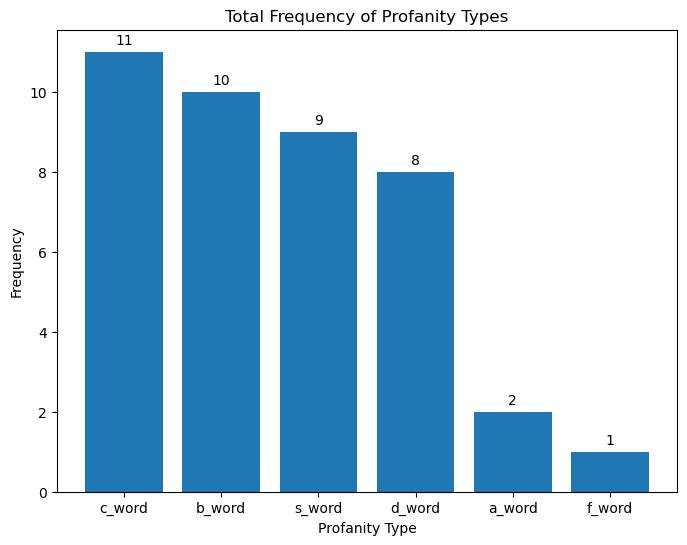

In [17]:
# sort from highest to lowest frequency
profanity_totals = profanity_totals.sort_values(ascending=False)

# bar plotting
plt.figure(figsize=(8, 6))
bars = plt.bar(profanity_totals.index, profanity_totals.values)

# add frequency labels
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.1, str(int(y)),
             ha='center', va='bottom')

plt.title("Total Frequency of Profanity Types")
plt.xlabel("Profanity Type")
plt.ylabel("Frequency")
plt.show()

#### Interpretation of Profanity Patterns

In absolute terms, these bad words do not appear very often, which suggests that commenters under YouTube economy videos are relatively civil overall.

Looking more closely at the profanity categories I defined, the more common ones are `c-words,` mainly *crap;* `b-words`, mainly *bullshit;* `s-words,` mainly *shit;* and `d-words,` mainly *damn.* To be fair, I do not think these words are especially aggressive on their own. In many cases, they seem to be used more to express disagreement with an opinion or statement, such as calling an idea *crap* or *bullshit,* or to show a strong emotional reaction, like saying *damn.* They do not necessarily rise to the level of direct personal attack. By contrast, more clearly insulting words such as *ass* and *fuck appear* very rarely, with frequencies of only 2 and 1, respectively. This further supports my interpretation that the overall community tone in the comments under these YouTube economy videos is still fairly friendly.

Another interesting inference is that some common bad words, such as *fucking* and *shitty,* did not appear at all in the data I collected. This may partly be due to sample size, but I think it also reflects differences in language norms across social media platforms. In my experience, I see these words much more often on platforms like Instagram and other more casual or emotionally expressive spaces.

### Topic Discovery with Topic Modeling

After examining term frequencies and tone-related signals, the next step is to identify broader thematic structure in the corpus using topic modeling.

The goal is not to produce perfect or definitive categories, but to uncover recurring word clusters that suggest interpretable themes in economy-related public discussion.

#### Modeling Decisions

Before running topic modeling, I define a few modeling choices that are likely to affect interpretability.

Because YouTube comments are short and noisy, topic quality depends heavily on preprocessing decisions, vocabulary selection, and the number of topics. I start with a relatively simple modeling setup and then compare alternative topic counts to see whether the resulting themes become more coherent.

In [18]:
!pip install nltk --quiet

In [19]:
!pip install gensim

In [ ]:
# download the tagger 
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt_tab to /home/jovyan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [ ]:
# create a function to pull out nouns from a string of text
from nltk import word_tokenize, pos_tag

def nouns(text):
    '''Given a string of text, tokenize the text and pull out only the nouns.'''
    is_noun = lambda pos: pos[:2] == 'NN'
    tokenized = word_tokenize(text)
    all_nouns = [word for (word, pos) in pos_tag(tokenized) if is_noun(pos)]
    return ' '.join(all_nouns)

In [ ]:
# apply the nouns function to the transcripts to filter only on nouns
data_nouns = pd.DataFrame(df['comment_title'].apply(nouns))
data_nouns.head()

,comment_title
0,America
1,bankruptcy life usa
2,Gold
3,world doesn ’ t trust dollar trump maga truth ...
4,day gold ....


In [ ]:
# recreate a document-term matrix with only nouns
cvn = CountVectorizer(stop_words=stop_words)
data_cvn = cvn.fit_transform(data_nouns['comment_title'])
data_dtmn = pd.DataFrame(data_cvn.toarray(), columns=cvn.get_feature_names_out())
data_dtmn.index = data_nouns.index
data_dtmn

,000,100,1600s,19,21,26,36ut1nc9o3vgj9_v,5qlfvwcm_bvorbj4,6jywd_xuxfe,700,...,zilch,zimbabwean,zip,zips,zombie,zone,zwykłym,zzz,übersetzung,że
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2913,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2914,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2915,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2916,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from gensim import matutils, models
import scipy.sparse

# create the gensim corpus
corpusn = matutils.Sparse2Corpus(scipy.sparse.csr_matrix(data_dtmn.transpose()))

# create the vocabulary dictionary
id2wordn = dict((v, k) for k, v in cvn.vocabulary_.items())

In [25]:
# start with 2 topics
ldan = models.LdaModel(corpus=corpusn, num_topics=2, id2word=id2wordn, passes=10)
ldan.print_topics()

[(0,
  '0.025*"prices" + 0.013*"trump" + 0.011*"year" + 0.009*"president" + 0.009*"country" + 0.008*"price" + 0.007*"tax" + 0.007*"taxes" + 0.007*"food" + 0.005*"years"'),
 (1,
  '0.031*"trump" + 0.026*"people" + 0.015*"economy" + 0.009*"insurance" + 0.008*"money" + 0.007*"news" + 0.007*"president" + 0.007*"biden" + 0.007*"way" + 0.007*"government"')]

In [26]:
# try 3 topics
ldan = models.LdaModel(corpus=corpusn, num_topics=3, id2word=id2wordn, passes=10)
ldan.print_topics()

[(0,
  '0.024*"trump" + 0.020*"economy" + 0.019*"president" + 0.019*"prices" + 0.014*"people" + 0.013*"money" + 0.012*"biden" + 0.011*"year" + 0.010*"time" + 0.009*"tax"'),
 (1,
  '0.035*"trump" + 0.020*"people" + 0.015*"prices" + 0.012*"insurance" + 0.008*"inflation" + 0.007*"food" + 0.007*"world" + 0.007*"america" + 0.007*"price" + 0.007*"news"'),
 (2,
  '0.014*"people" + 0.012*"country" + 0.008*"lies" + 0.006*"lol" + 0.005*"news" + 0.005*"https" + 0.005*"economy" + 0.004*"america" + 0.004*"thing" + 0.004*"bs"')]

#### First Topic Modeling Attempt

First, the 3-topic version is clearer than the 2-topic version. With only 2 topics, each topic feels more mixed and tends to combine politics, everyday economic concerns, national-level issues, taxation, and news-related discussion all at once. In comparison, when I use 3 topics, I can roughly separate them into the following categories:

- Topic 0: Trump government’s economic performance

- Topic 1: everyday cost-of-living concerns

- Topic 2: reactions to economic news

Based on these categories, I think Topic 0 and Topic 1 are both closely related to the economy topic, and they are also reasonably distinct because they approach the economy from different angles. For that reason, I think these two topics work fairly well. However, Topic 2 is more focused on reactions to news coverage, and its connection to the economy itself is not as strong. To me, this suggests that the topic modeling still has some limitations in this first attempt, so I decided to move on to a second attempt.

### Refining the Topic Model

#### Revised Modeling Strategy

The first modeling attempt produced partially useful results, but the topics still felt somewhat broad and mixed. To improve interpretability, I conducted a second round of modeling with a refined feature-selection strategy.

This second attempt builds on the earlier model but adjusts the vocabulary in order to increase semantic coherence and reduce noise in the resulting topic structure.

In [ ]:
# create a function to pull out nouns + adjs from a string of text
def nouns_adj(text):
    '''Given a string of text, tokenize the text and pull out only the nouns and adjectives.'''
    is_noun_adj = lambda pos: pos[:2] == 'NN' or pos[:2] == 'JJ'
    tokenized = word_tokenize(text)
    nouns_adj = [word for (word, pos) in pos_tag(tokenized) if is_noun_adj(pos)]
    return ' '.join(nouns_adj)

In [ ]:
# apply the function to the transcripts to filter only on nouns
data_nouns_adjs = pd.DataFrame(df['comment_title'].apply(nouns_adj))
data_nouns_adjs.head()

,comment_title
0,America toast
1,yugest bankruptcy life usa
2,Gold economic stable
3,world doesn ’ t trust dollar trump maga truth ...
4,day invest gold ....


In [ ]:
# recreate a document-term matrix with nouns + adjs
cvn = CountVectorizer(stop_words=stop_words)
data_cvn = cvn.fit_transform(data_nouns_adjs['comment_title'])
data_dtmn = pd.DataFrame(data_cvn.toarray(), columns=cvn.get_feature_names_out())
data_dtmn.index = data_nouns_adjs.index
data_dtmn

,000,10,100,12,1600s,19,1900,1970,1980,1993,...,zilch,zimbabwean,zip,zips,zombie,zone,zwykłym,zzz,übersetzung,że
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2913,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2914,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2915,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2916,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
# create the gensim corpus
corpusn = matutils.Sparse2Corpus(scipy.sparse.csr_matrix(data_dtmn.transpose()))

# create the vocabulary dictionary
id2wordn = dict((v, k) for k, v in cvn.vocabulary_.items())

In [31]:
# try 3 topics
ldan = models.LdaModel(corpus=corpusn, num_topics=3, id2word=id2wordn, passes=10)
ldan.print_topics()

[(0,
  '0.021*"trump" + 0.018*"people" + 0.016*"president" + 0.013*"money" + 0.011*"america" + 0.010*"american" + 0.009*"great" + 0.007*"time" + 0.006*"news" + 0.006*"inflation"'),
 (1,
  '0.028*"prices" + 0.015*"people" + 0.010*"insurance" + 0.009*"economy" + 0.008*"year" + 0.008*"price" + 0.007*"high" + 0.006*"years" + 0.006*"cost" + 0.006*"costs"'),
 (2,
  '0.040*"trump" + 0.008*"jobs" + 0.007*"country" + 0.007*"economy" + 0.006*"thing" + 0.006*"good" + 0.005*"politicians" + 0.005*"world" + 0.005*"maga" + 0.005*"people"')]

#### Refined Topic Interpretation

In the revised model, the 3-topic structure becomes more interpretable. The resulting themes can be summarized as:

- **Topic 0:** reactions to the Trump administration’s economic performance  
- **Topic 1:** everyday cost-of-living concerns, including prices and affordability  
- **Topic 2:** media, policy, and broader public response to economic conditions  

Although these labels are still interpretive rather than definitive, the second attempt provides a more coherent and analytically useful topic structure than the first.